### Анализ ассортимента продуктового магазина
1. По какой категории товаров продано больше всего позиций?
2. Оценить распределение количества проданных позиций
3. Какой средний чек был 13.01.2022?
4. Рассчитать долю товаров в категории "Сыры"
5. Рассчитайте маржу по всем категориям level1
6. ABC анализ

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
products = pd.read_excel('data/store_products.xlsx')

In [4]:
orders = pd.read_excel('data/store_orders.xlsx')

In [5]:
products.head()

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


In [6]:
orders.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [7]:
# объединили две таблицы в одну по id
merged_df = products.merge(orders, on='product_id')

In [8]:
merged_df.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14


In [9]:
merged_df.describe()

,product_id,order_id,accepted_at,quantity,regular_price,price,cost_price
count,3018.000000,3.018000e+03,3018,3018.000000,3018.000000,3018.000000,3018.000000
mean,18915.801856,1.517529e+09,2022-01-13 16:04:47.241882,1.236581,137.763751,128.719682,80.373426
min,23.000000,1.517207e+09,2022-01-13 08:00:30,1.000000,11.000000,4.000000,7.000000
25%,5393.250000,1.517453e+09,2022-01-13 12:51:39,1.000000,75.000000,71.000000,42.000000
50%,10756.000000,1.517526e+09,2022-01-13 16:26:22,1.000000,115.000000,106.000000,66.000000
75%,24160.000000,1.517607e+09,2022-01-13 19:24:06.750000,1.000000,175.000000,162.750000,99.000000
max,111797.000000,1.517855e+09,2022-01-13 22:58:29,12.000000,1797.000000,1797.000000,808.000000
std,21792.443582,1.031607e+05,NaN,0.787515,104.052421,95.762316,61.475386


## Количество проданных товаров по категориям level1

In [10]:
df = merged_df.groupby('level1').agg({'quantity': sum}).reset_index().sort_values('quantity', ascending=False)
df.head(5)

,level1,quantity
1,Безалкогольные напитки,534
11,Молочная продукция,483
19,Свежие овощи,262
10,Кулинария,250
0,Бакалея,239


/var/folders/4g/ybnkwh793rb53vbrq1hfsp5c0000gn/T/ipykernel_82658/1198001975.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=df['level1'], y=df['quantity'], palette='Set2')


[Text(0.5, 0, 'Название категории'),
 Text(0, 0.5, 'Количество проданного товара')]

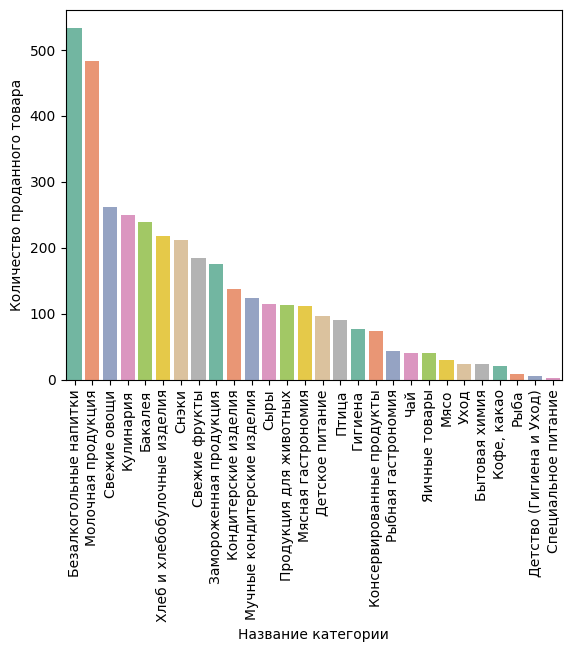

In [ ]:
plot = sns.barplot(x=df['level1'], y=df['quantity'], palette='Set2')

plt.setp(plot.get_xticklabels(), rotation=90)
plot.set(xlabel='Название категории', ylabel='Количество проданного товара')

## Распределение продаж по подкатегориям

In [12]:
df = merged_df.groupby(['level1', 'level2']).agg({'quantity': sum}).reset_index().sort_values('quantity', ascending=False)
df.head(10)

,level1,level2,quantity
13,Безалкогольные напитки,Напитки,252
54,Кулинария,Готовые блюда,248
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
86,Снэки,Снэки соленые,180
12,Безалкогольные напитки,Воды питьевые,162
78,Свежие овощи,"Корнеплоды, зелень и прочие овощи",157
60,Молочная продукция,Молоко и сливки,147
61,Молочная продукция,Молочно-десертные продукты,116
81,Свежие фрукты,"Цитрусовые, семечковые и прочие плоды",108
57,Молочная продукция,Кисломолочные традиционные продукты,106


## Средний чек 13.01.2022

In [13]:
orders[orders['accepted_at'].dt.strftime('%Y-%m-%d') == '2022-01-13'].groupby('order_id')['price'].sum().reset_index()['price'].mean()

np.float64(798.0422794117648)

## Доля промо в категории Сыры

In [14]:
df = merged_df[merged_df['level1'] == 'Сыры']
# Добавили новый столбец Промо
df['is_promo'] = (df['regular_price'] > df['price'])
df.head(5)

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price,is_promo
116,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517510145,2022-01-13 19:22:00,2,129,129,73,False
117,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517609703,2022-01-13 08:46:56,1,116,116,73,False
118,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517675616,2022-01-13 18:23:57,1,129,129,73,False
119,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517521855,2022-01-13 19:57:03,1,129,129,73,False
265,2134,Сыры,Твердые сычужные сыры,Сыр сливочный Брест-Литовск,1517668073,2022-01-13 22:43:39,1,199,159,110,True


In [15]:
df[df['is_promo'] == True]['is_promo'].count() / df['is_promo'].count()
# Доля акционных товаров

np.float64(0.32075471698113206)

In [16]:
m = {
    True: 'Промо',
    False: 'Не промо'
}

df = df.groupby('is_promo')['level1'].count().reset_index()
df['is_promo'] = df['is_promo'].map(m)

In [17]:
df.head()

,is_promo,level1
0,Не промо,72
1,Промо,34


([<matplotlib.patches.Wedge at 0x11c1c1d30>,
 [Text(-0.5872058044694825, 0.9301555478506529, 'Не промо'),
  Text(0.5872056640198955, -0.9301556365162519, 'Промо')],
 [Text(-0.3202940751651722, 0.5073575715549015, '68%'),
  Text(0.32029399855630664, -0.5073576199179556, '32%')])

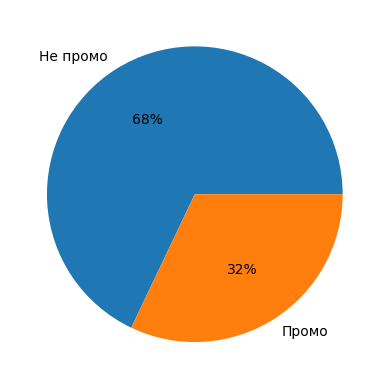

In [18]:
plt.pie(df['level1'], labels=df['is_promo'], autopct='%.0f%%')

## Маржа по категориям

In [19]:
def calc_margin(x):
    d = {}
    d['margin_rub'] = sum(x['price']) - sum(x['cost_price'])
    d['margin_perc'] = d['margin_rub'] / sum(x['price'])
    return pd.Series(d, index=['margin_rub', 'margin_perc'])

In [20]:
merged_df.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14


In [21]:
df = merged_df.groupby('level1').apply(calc_margin).reset_index()
df

,level1,margin_rub,margin_perc
0,Бакалея,7224.0,0.383663
1,Безалкогольные напитки,15163.0,0.443103
2,Бытовая химия,1420.0,0.261270
3,Гигиена,2704.0,0.293466
4,Детское питание,1272.0,0.370306
5,Детство (Гигиена и Уход),517.0,0.299017
6,Замороженная продукция,11057.0,0.474244
7,Кондитерские изделия,4910.0,0.423130
8,Консервированные продукты,3635.0,0.420328
9,"Кофе, какао",3529.0,0.509382


/var/folders/4g/ybnkwh793rb53vbrq1hfsp5c0000gn/T/ipykernel_82658/855178187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_plot, y='level1', x='margin_rub', orient='h', palette='viridis')


[Text(0.5, 0, 'Маржа (руб)'), Text(0, 0.5, 'Категория товара')]

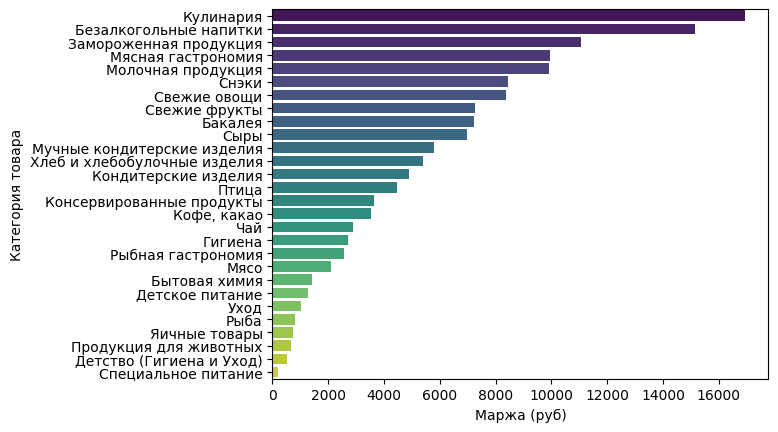

In [22]:
df_plot = df.sort_values('margin_rub', ascending=False)

plot = sns.barplot(data=df_plot, y='level1', x='margin_rub', orient='h', palette='viridis')
plot.set(xlabel='Маржа (руб)', ylabel='Категория товара')

/var/folders/4g/ybnkwh793rb53vbrq1hfsp5c0000gn/T/ipykernel_82658/2376937905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_plot, y='level1', x='margin_perc', orient='h', palette='viridis')


[Text(0.5, 0, 'Маржа (%)'), Text(0, 0.5, 'Категория товара')]

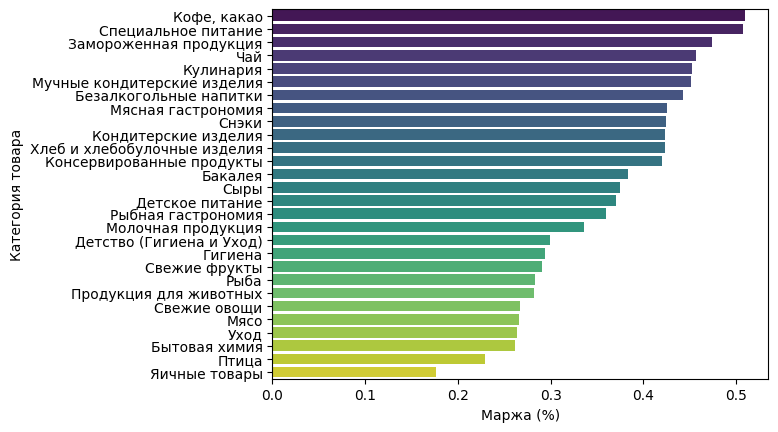

In [23]:
df_plot = df.sort_values('margin_perc', ascending=False)

plot = sns.barplot(data=df_plot, y='level1', x='margin_perc', orient='h', palette='viridis')
plot.set(xlabel='Маржа (%)', ylabel='Категория товара')

## ABC анализ

In [ ]:
df = merged_df.groupby('level2').agg({'price': sum, 'quantity': sum}).reset_index()

df = df.sort_values('price', ascending=False)
df['price_contribution'] = df['price'] / sum(df['price'])
df['price_cumsum'] = df['price_contribution'].cumsum()

def set_abc(x):
    if x < 0.8:
        return 'A'
    elif x < 0.95:
        return 'B'
    else:
        return 'C'

df['ABC_price'] = df['price_cumsum'].apply(set_abc)

df = df.sort_values('quantity', ascending=False)
df['quantity_contribution'] = df['quantity'] / sum(df['quantity'])
df['quantity_cumsum'] = df['quantity_contribution'].cumsum()
df['ABC_quantity'] = df['quantity_cumsum'].apply(set_abc)

df['ABC_join'] = df.filter(like='ABC').apply(' '.join, axis=1)
df

/tmp/ipykernel_168/3931049400.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = merged_df.groupby('level2').agg({'price': sum, 'quantity': sum}).reset_index()
/tmp/ipykernel_168/3931049400.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = merged_df.groupby('level2').agg({'price': sum, 'quantity': sum}).reset_index()


,level2,price,quantity,price_contribution,price_cumsum,ABC_price,quantity_contribution,quantity_cumsum,ABC_quantity,ABC_join
51,Напитки,18320,252,0.047159,0.192202,A,0.067524,0.067524,A,A A
10,Готовые блюда,36944,248,0.095100,0.095100,A,0.066452,0.133976,A,A A
92,Хлеб и хлебобулочные изделия,12722,218,0.032748,0.420119,A,0.058414,0.192390,A,A A
72,Снэки соленые,15178,180,0.039071,0.318331,A,0.048232,0.240622,A,A A
6,Воды питьевые,5807,162,0.014948,0.702998,A,0.043408,0.284030,A,A A
...,...,...,...,...,...,...,...,...,...,...
4,Влажные салфетки,255,2,0.000656,0.996661,C,0.000536,0.998392,C,C C
57,Первая помощь,168,2,0.000432,0.999421,C,0.000536,0.998928,C,C C
24,"Какао, горячий шоколад",238,2,0.000613,0.997889,C,0.000536,0.999464,C,C C
77,Средства для сантехники,239,1,0.000615,0.997277,C,0.000268,0.999732,C,C C


In [ ]:
df.filter(like='ABC').apply(' '.join, axis=1)

,0
51,A A A A
10,A A A A
92,A A A A
72,A A A A
6,A A A A
...,...
4,C C C C
57,C C C C
24,C C C C
77,C C C C
